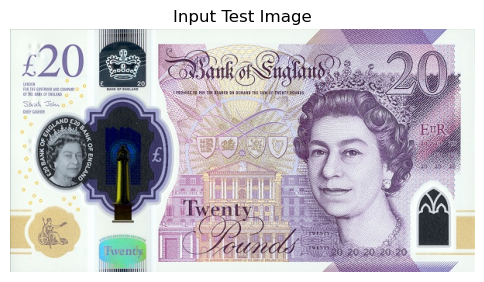

In [26]:
import cv2
import matplotlib.pyplot as plt

# Your image path
image_path = r"test.jpg"

# Read image
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Input Test Image")
plt.axis("off")
plt.show()

In [28]:
import torch
import timm

yolo_path = r"yolo_gbp_best.pt"
cls_path  = r"mobilenetv3_small_best.pth"

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load YOLO
from ultralytics import YOLO
yolo_model = YOLO(yolo_path)

num_classes = 11  

classifier = timm.create_model("mobilenetv3_small_100",
                                pretrained=False,
                                num_classes=num_classes)

checkpoint = torch.load(cls_path, map_location=device)

classifier.load_state_dict(checkpoint["state_dict"])
classifier.to(device)
classifier.eval()

print("Models loaded successfully with", num_classes, "classes")

Models loaded successfully with 11 classes


In [29]:
checkpoint = torch.load(cls_path, map_location="cpu")
print(checkpoint["state_dict"]["classifier.weight"].shape)

torch.Size([11, 1024])


In [32]:
IMG_SIZE = 224

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),
                         (0.229, 0.224, 0.225))
])

In [34]:
results = yolo_model.predict(img, conf=0.35)

annotated = img.copy()

class_names = ["GBP_5", "GBP_10", "GBP_20"]  

for r in results:
    for box in r.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])
        
        crop = img[y1:y2, x1:x2]
        if crop.size == 0:
            continue
        
        # Classification
        rgb_crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        input_tensor = transform(rgb_crop).unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = classifier(input_tensor)
            probs = torch.softmax(output, dim=1)
            pred = torch.argmax(probs, dim=1).item()
        
        label = class_names[pred]
        score = probs[0][pred].item()

        # Draw box
        cv2.rectangle(annotated, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(annotated, f"{label} ({score*100:.1f}%)",
                    (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, (0,255,0), 2)


0: 352x640 1 20 pounds, 69.3ms
Speed: 2.2ms preprocess, 69.3ms inference, 1.1ms postprocess per image at shape (1, 3, 352, 640)


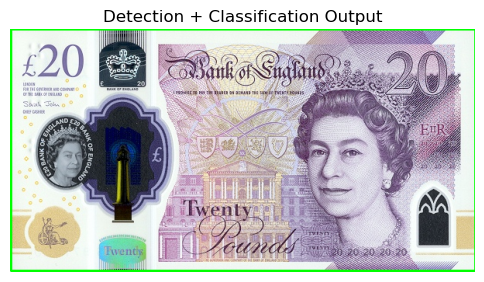

In [36]:
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(annotated_rgb)
plt.title("Detection + Classification Output")
plt.axis("off")
plt.show()